First 5 rows:
   PassengerId  Survived  Pclass                          Name     Sex  Age  \
0            1         0       3       Braund, Mr. Owen Harris    male   22   
1            2         1       1    Cumings, Mrs. John Bradley  female   38   
2            3         1       3        Heikkinen, Miss. Laina  female   26   
3            4         1       1  Futrelle, Mrs. Jacques Heath  female   35   
4            5         0       3      Allen, Mr. William Henry    male   35   

   SibSp  Parch            Ticket     Fare Cabin Embarked  
0      1      0         A/5 21171   7.2500   NaN        S  
1      1      0          PC 17599  71.2833   C85        C  
2      0      0  STON/O2. 3101282   7.9250   NaN        S  
3      1      0            113803  53.1000  C123        S  
4      0      0            373450   8.0500   NaN        S  

Dataset Shape:
(20, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'C

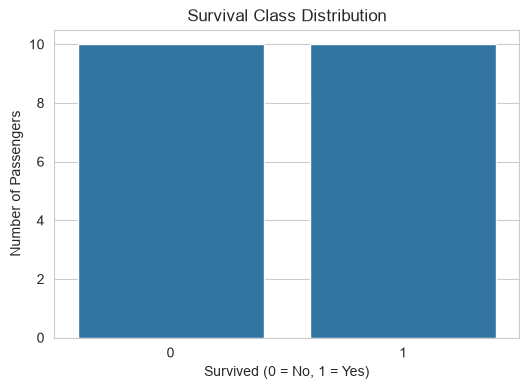


Gender Representation:
Sex
female    11
male       9
Name: count, dtype: int64


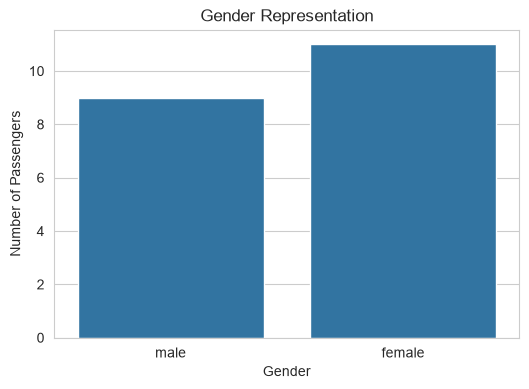


Survival by Gender:
Survived  0  1
Sex           
female    2  9
male      8  1


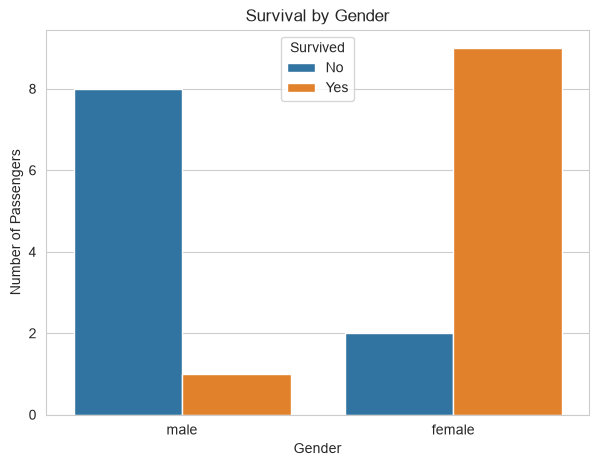


Passenger Class Representation:
Pclass
1     4
2     3
3    13
Name: count, dtype: int64


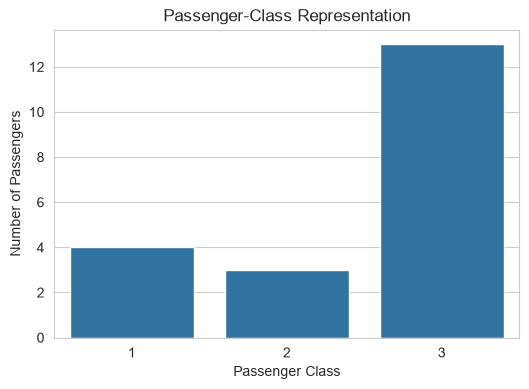


Survival by Passenger Class:
Survived  0  1
Pclass        
1         1  3
2         0  3
3         9  4


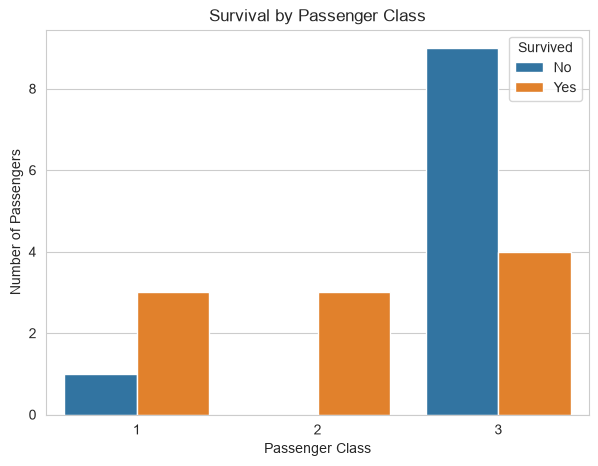


Age Group Distribution:
AgeGroup
Child           3
Teenager        2
Young Adult    10
Adult           5
Senior          0
Name: count, dtype: int64


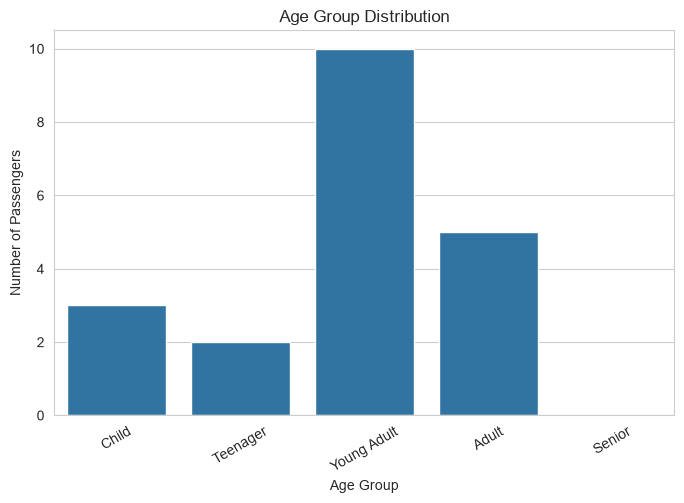


Survival by Age Group:
Survived     0  1
AgeGroup         
Child        2  1
Teenager     1  1
Young Adult  5  5
Adult        2  3


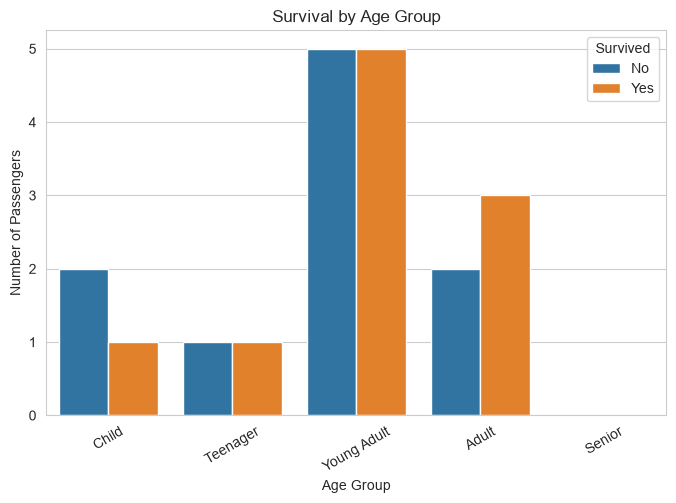


12. POSSIBLE BIAS

Survival Percentage by Gender:
Survived          0          1
Sex                           
female    18.181818  81.818182
male      88.888889  11.111111

Survival Percentage by Passenger Class:
Survived          0           1
Pclass                         
1         25.000000   75.000000
2          0.000000  100.000000
3         69.230769   30.769231

Survival Percentage by Age Group:
Survived             0          1
AgeGroup                         
Child        66.666667  33.333333
Teenager     50.000000  50.000000
Young Adult  50.000000  50.000000
Adult        40.000000  60.000000
Priti Yadav T054


In [5]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Set graph style
sns.set_style("whitegrid")
# 1. Load and Explore the Dataset
df = pd.read_csv("Titanic_train.csv")
print("First 5 rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
# 2. Check Data Quality
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())
print("\nData Types:")
print(df.dtypes)
# 3. Identify the Target Variable
target = "Survived"
print("\nTarget Variable:", target)
print("Target Values:")
print(df[target].unique())
# 4. Analyze Class Distribution
print("\nClass Distribution:")
print(df["Survived"].value_counts())
print("\nClass Distribution Percentage:")
print(df["Survived"].value_counts(normalize=True) * 100)
# 5. Visualize Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived")
plt.title("Survival Class Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()
# 6. Analyze Gender Representation
print("\nGender Representation:")
print(df["Sex"].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex")
plt.title("Gender Representation")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()
# 7. Analyze Survival by Gender
print("\nSurvival by Gender:")
print(pd.crosstab(df["Sex"], df["Survived"]))
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()
# 8. Analyze Passenger-Class Representation
print("\nPassenger Class Representation:")
print(df["Pclass"].value_counts().sort_index())
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pclass")
plt.title("Passenger-Class Representation")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()
# 9. Analyze Survival by Passenger Class
print("\nSurvival by Passenger Class:")
print(pd.crosstab(df["Pclass"], df["Survived"]))
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()
# 10. Analyze Age Groups
# Create age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)
print("\nAge Group Distribution:")
print(df["AgeGroup"].value_counts().sort_index())
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="AgeGroup",
    order=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=30)
plt.show()
# 11. Analyze Survival by Age Group
print("\nSurvival by Age Group:")
print(pd.crosstab(df["AgeGroup"], df["Survived"]))
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="AgeGroup",
    hue="Survived",
    order=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)
plt.title("Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=30)
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()
# 12. IDENTIFY POSSIBLE BIAS
print("\n12. POSSIBLE BIAS")
# Gender bias analysis
gender_bias = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

print("\nSurvival Percentage by Gender:")
print(gender_bias)
# Passenger class bias analysis
class_bias = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100
print("\nSurvival Percentage by Passenger Class:")
print(class_bias)
# Age group bias analysis
age_bias = pd.crosstab(
    df["AgeGroup"],
    df["Survived"],
    normalize="index"
) * 100
print("\nSurvival Percentage by Age Group:")
print(age_bias)
print("Priti Yadav T054")

First 5 rows:
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own          little           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little           little           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   Duration              Purpose  Risk  
0         6             radio/TV  good  
1        48             radio/TV   bad  
2        12            education  good  
3        42  furniture/equipment  good  
4        24                  car   bad  

Dataset Shape:
(20, 10)

Column Names:
Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries,

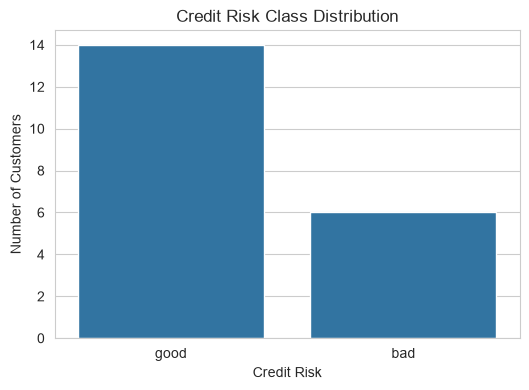


Gender Representation:
Sex
male      14
female     6
Name: count, dtype: int64


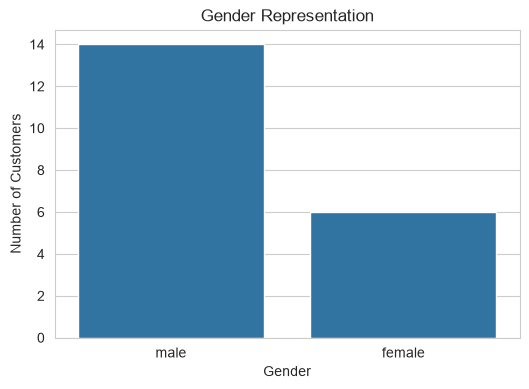


Credit Risk by Gender:
Risk    bad  good
Sex              
female    4     2
male      2    12


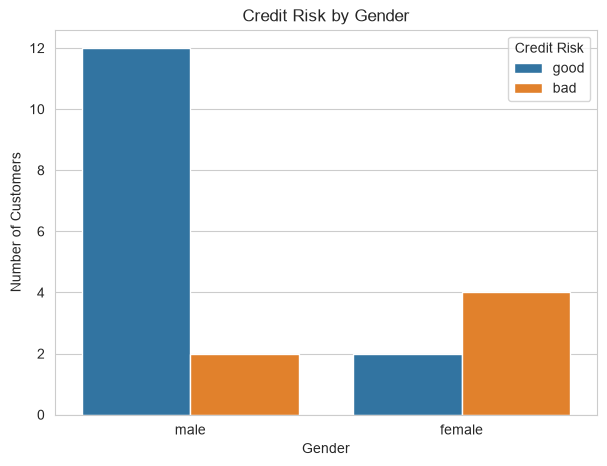


Age Group Distribution:
AgeGroup
Young (18-25)          4
Adult (26-35)          7
Middle Age (36-50)     4
Older Adult (51-65)    4
Senior (66+)           1
Name: count, dtype: int64


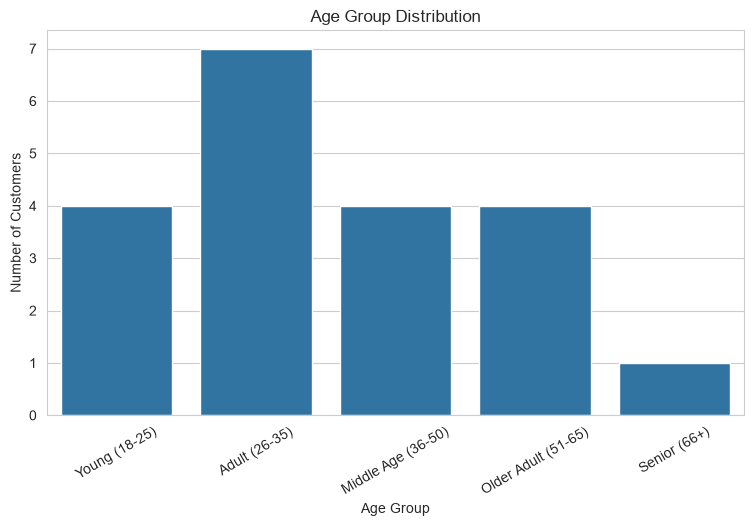


Credit Risk by Age Group:
Risk                 bad  good
AgeGroup                      
Young (18-25)          4     0
Adult (26-35)          1     6
Middle Age (36-50)     0     4
Older Adult (51-65)    1     3
Senior (66+)           0     1


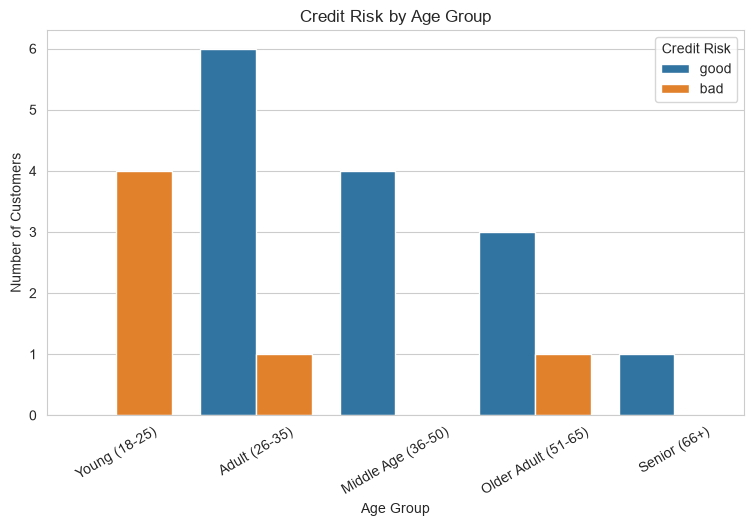


Housing Category Representation:
Housing
own     12
rent     5
free     3
Name: count, dtype: int64


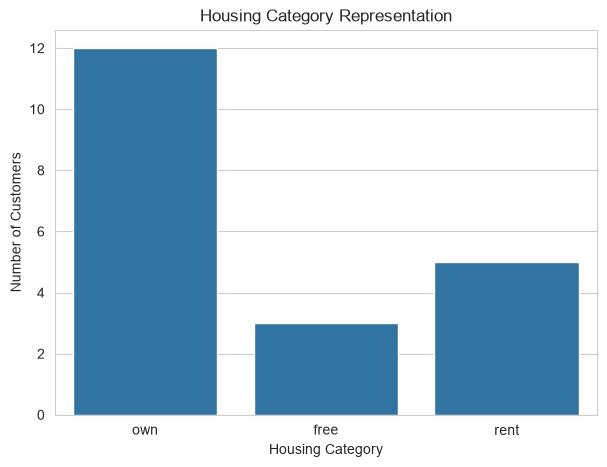


Credit Risk by Housing Category:
Risk     bad  good
Housing           
free       1     2
own        2    10
rent       3     2


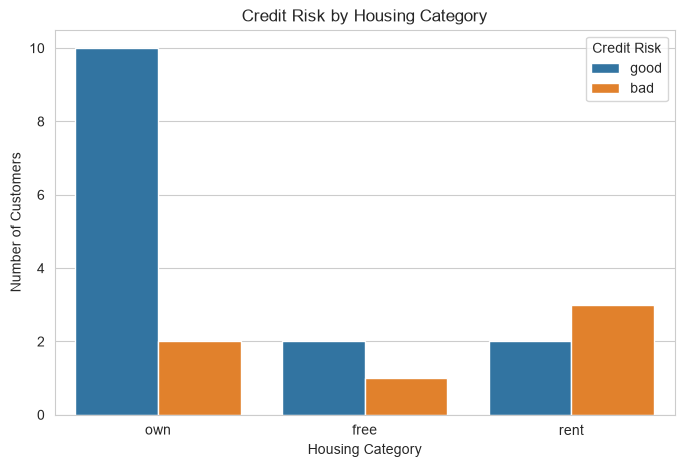


12. POSSIBLE BIAS

Credit Risk Percentage by Gender:
Risk          bad       good
Sex                         
female  66.666667  33.333333
male    14.285714  85.714286

Credit Risk Percentage by Age Group:
Risk                        bad        good
AgeGroup                                   
Young (18-25)        100.000000    0.000000
Adult (26-35)         14.285714   85.714286
Middle Age (36-50)     0.000000  100.000000
Older Adult (51-65)   25.000000   75.000000
Senior (66+)           0.000000  100.000000

Credit Risk Percentage by Housing:
Risk           bad       good
Housing                      
free     33.333333  66.666667
own      16.666667  83.333333
rent     60.000000  40.000000
Priti Yadav T054


In [7]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set graph style
sns.set_style("whitegrid")


# 1. Load and Explore the Dataset

df = pd.read_csv("German_Credit_Risk.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


# 2. Check Data Quality

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)


# 3. Identify the Target Variable

target = "Risk"

print("\nTarget Variable:", target)

print("Target Values:")
print(df[target].unique())


# 4. Analyze Class Distribution

print("\nClass Distribution:")
print(df["Risk"].value_counts())

print("\nClass Distribution Percentage:")
print(df["Risk"].value_counts(normalize=True) * 100)


# 5. Visualize Class Imbalance

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Risk")

plt.title("Credit Risk Class Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")

plt.show()


# 6. Analyze Gender Representation

print("\nGender Representation:")
print(df["Sex"].value_counts())

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Sex")

plt.title("Gender Representation")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()


# 7. Analyze Credit Risk by Gender

print("\nCredit Risk by Gender:")
print(pd.crosstab(df["Sex"], df["Risk"]))

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Sex", hue="Risk")

plt.title("Credit Risk by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Credit Risk")

plt.show()


# 8. Analyze Age Groups

# Create age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=[
        "Young (18-25)",
        "Adult (26-35)",
        "Middle Age (36-50)",
        "Older Adult (51-65)",
        "Senior (66+)"
    ]
)

print("\nAge Group Distribution:")
print(df["AgeGroup"].value_counts().sort_index())

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="AgeGroup",
    order=[
        "Young (18-25)",
        "Adult (26-35)",
        "Middle Age (36-50)",
        "Older Adult (51-65)",
        "Senior (66+)"
    ]
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.show()


# 9. Analyze Credit Risk by Age Group

print("\nCredit Risk by Age Group:")
print(pd.crosstab(df["AgeGroup"], df["Risk"]))

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="AgeGroup",
    hue="Risk",
    order=[
        "Young (18-25)",
        "Adult (26-35)",
        "Middle Age (36-50)",
        "Older Adult (51-65)",
        "Senior (66+)"
    ]
)

plt.title("Credit Risk by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.legend(title="Credit Risk")

plt.show()


# 10. Analyze Housing Category Representation

print("\nHousing Category Representation:")
print(df["Housing"].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Housing")

plt.title("Housing Category Representation")
plt.xlabel("Housing Category")
plt.ylabel("Number of Customers")

plt.show()


# 11. Analyze Credit Risk by Housing Category

print("\nCredit Risk by Housing Category:")
print(pd.crosstab(df["Housing"], df["Risk"]))

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Housing", hue="Risk")

plt.title("Credit Risk by Housing Category")
plt.xlabel("Housing Category")
plt.ylabel("Number of Customers")
plt.legend(title="Credit Risk")

plt.show()


# 12. IDENTIFY POSSIBLE BIAS

print("\n12. POSSIBLE BIAS")

# Gender bias analysis
gender_bias = pd.crosstab(
    df["Sex"],
    df["Risk"],
    normalize="index"
) * 100

print("\nCredit Risk Percentage by Gender:")
print(gender_bias)


# Age group bias analysis
age_bias = pd.crosstab(
    df["AgeGroup"],
    df["Risk"],
    normalize="index"
) * 100

print("\nCredit Risk Percentage by Age Group:")
print(age_bias)


# Housing bias analysis
housing_bias = pd.crosstab(
    df["Housing"],
    df["Risk"],
    normalize="index"
) * 100

print("\nCredit Risk Percentage by Housing:")
print(housing_bias)


print("Priti Yadav T054")